# Extreme precipitation: Changes under climate scenarios — Kazakhstan
# [Hazard assessment]

Adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and
[HEAVY_RAINFALL](https://github.com/CLIMAAX/HEAVY_RAINFALL) GitHub repository.

## Data Substitutions

| Original (CLIMAAX / Europe) | Kazakhstan Replacement | Reason |
|---|---|---|
| EURO-CORDEX precipitation via `cdsapi` / Copernicus CDS | ISIMIP3b bias-adjusted daily `pr` (direct HTTP, no API key) | EURO-CORDEX covers Europe only |
| Rotated-pole CRS `RotatedPole(pole_lat=39.25, pole_lon=-162)` | Regular WGS84 lat/lon (EPSG:4326) | ISIMIP3b uses standard lat/lon; no reprojection needed |
| `cdsapi` library | `urllib` direct download | No API key required for ISIMIP3b |
| RCP scenarios (RCP4.5, RCP8.5) | SSP scenarios (SSP1-2.6, SSP3-7.0) | ISIMIP3b uses CMIP6 SSP framework |
| Single GCM/RCM chain | 5 ISIMIP3b models, multi-model mean IDF | Ensemble mean reduces single-model uncertainty |
| Catalonia bounding box + rotated-pole coords | Kazakhstan WGS84 bounding box | Geographic adaptation |
| 3h **and** 24h durations | 24h only | ISIMIP3b provides daily data; sub-daily resolution unavailable |
| `cartopy` rotated-pole projection for maps | `cartopy` PlateCarree | Standard projection for regular lat/lon |

**Time frames:**
- Historical baseline: 1976–2005
- Future: 2041–2070 under SSP1-2.6 and SSP3-7.0

**Models:** GFDL-ESM4, IPSL-CM6A-LR, MPI-ESM1-2-HR, MRI-ESM2-0, UKESM1-0-LL

**Scientific note:** 24h annual maxima are used directly from ISIMIP3b daily `pr`
(kg m⁻² s⁻¹ × 86400 = mm/day). The rolling-sum accumulation logic from the
original (window = duration / t_step) reduces to window = 1 for 24h data, which
is equivalent to using daily maxima directly. The GEV fitting and return-period
methodology are unchanged from the original CLIMAAX workflow.

## Prepare your workspace

In [1]:
# ---------------------------------------------------------------------------
# Libraries
# ---------------------------------------------------------------------------
import os
import glob
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import xarray as xr
import scipy.stats as sst
from scipy.stats import genextreme, ks_1samp
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import plotly.express as px
import plotly.graph_objects as go
import contextily as ctx

try:
    from tqdm import tqdm
except ImportError:
    # Fallback: tqdm not required
    def tqdm(iterable, **kwargs):
        return iterable

warnings.filterwarnings('ignore', category=RuntimeWarning)

### Configuration

In [ ]:
# ---------------------------------------------------------------------------
# REGION
# ---------------------------------------------------------------------------
# Bounding box for Kazakhstan [W, S, E, N] in EPSG:4326
bbox = [46.0, 40.5, 87.4, 55.5]
areaname = 'Kazakhstan'

# ---------------------------------------------------------------------------
# ISIMIP3b models
# ---------------------------------------------------------------------------
MODELS = [
    'GFDL-ESM4',
    'IPSL-CM6A-LR',
    'MPI-ESM1-2-HR',
    'MRI-ESM2-0',
    'UKESM1-0-LL',
]

# UKESM1-0-LL uses r1i1p1f2 in ISIMIP3b; all others use r1i1p1f1
ENSEMBLE_MEMBERS = {
    'GFDL-ESM4':      'r1i1p1f1',
    'IPSL-CM6A-LR':   'r1i1p1f1',
    'MPI-ESM1-2-HR':  'r1i1p1f1',
    'MRI-ESM2-0':     'r1i1p1f1',
    'UKESM1-0-LL':    'r1i1p1f2',
}

# ---------------------------------------------------------------------------
# TIME FRAMES
# Historical baseline: 1976–2005  |  Future: 2041–2070 for both SSPs
# ---------------------------------------------------------------------------
TIME_FRAMES = {
    'historical': ('1976', '2005'),
    'ssp126':     ('2041', '2070'),
    'ssp370':     ('2041', '2070'),
}
hist_ystart, hist_yend = TIME_FRAMES['historical']

# ---------------------------------------------------------------------------
# ANALYSIS PARAMETERS (unchanged from original CLIMAAX workflow)
# ---------------------------------------------------------------------------
RETURN_PERIODS = np.asarray([2, 5, 10, 25, 50, 100, 200, 500])
DISTRIBUTION   = genextreme    # GEV as first choice (Fisher & Tippett 1928)

# Return period to show on maps
RETURN_PERIOD_MAP = 100

# Example pixel for single-point plots
POINT_LAT   = 43.25
POINT_LON   = 76.92
POINT_LABEL = 'Almaty'

# ---------------------------------------------------------------------------
# PATHS
# ---------------------------------------------------------------------------
SHAPEFILE_PATH = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)

### Directory structure

In [3]:
workflow_dir     = Path('.')
general_data_dir = workflow_dir / 'general_data' / 'isimip3b' / 'pr'
data_dir         = workflow_dir / f'data_{areaname}'
results_dir      = workflow_dir / f'results_{areaname}'
plots_dir        = workflow_dir / f'plots_{areaname}'

for d in [general_data_dir, data_dir, results_dir, plots_dir]:
    d.mkdir(parents=True, exist_ok=True)

print('Directory structure ready.')

Directory structure ready.


## Step 1: Download ISIMIP3b daily precipitation data

ISIMIP3b bias-adjusted `pr` (precipitation flux, kg m⁻² s⁻¹) is freely available
via direct HTTP — no API key or registration required.

Files are stored in 10-year chunks. Only the decades covering the required
analysis windows are downloaded. 

After download the global file is clipped to Kazakhstan's bounding box and saved
locally; the full global file is then deleted to save disk space.

In [ ]:
ISIMIP3B_BASE = (
    'https://files.isimip.org/ISIMIP3b/InputData/climate/atmosphere/'
    'bias-adjusted/global/daily'
)

# ---------------------------------------------------------------------------
# Decade file boundaries needed for each scenario.
# Each tuple: (syear, eyear) matching ISIMIP3b filename convention exactly.
# Confirmed working pattern: gfdl-esm4_r1i1p1f1_w5e5_historical_pr_global_daily_1981_1990.nc
# Historical decades must cover 1976–2005; future decades must cover 2041–2070.
# ---------------------------------------------------------------------------
DECADES = {
    'historical': [
        ('1971', '1980'),
        ('1981', '1990'),
        ('1991', '2000'),
        ('2001', '2010'),
    ],
    'ssp126': [
        ('2041', '2050'),
        ('2051', '2060'),
        ('2061', '2070'),
    ],
    'ssp370': [
        ('2041', '2050'),
        ('2051', '2060'),
        ('2061', '2070'),
    ],
}



def download_and_clip_isimip3b_pr(model, scenario, syear, eyear):

    fname    = f'{model}_{scenario}_{syear}_{eyear}_kaz_daily_pr.nc'

    drought_path = EXISTING_PR_DIR / fname
    if drought_path.exists():
        print(f'  Reusing from drought data : {fname}')
        return drought_path

    # Check this workflow's own cache
    local_path = general_data_dir / fname
    if local_path.exists():
        print(f'  Cached locally            : {fname}')
        return local_path

    # Not found anywhere — must download
    print(f'  Not cached, downloading   : {fname}')

    model_lower  = model.lower()
    ensemble     = ENSEMBLE_MEMBERS[model]
    remote_fname = (
        f'{model_lower}_{ensemble}_w5e5_{scenario}_pr_global_daily'
        f'_{syear}_{eyear}.nc'
    )
    url      = f'{ISIMIP3B_BASE}/{scenario}/{model}/{remote_fname}'
    tmp_path = general_data_dir / f'_tmp_{remote_fname}'

    print(f'  Downloading: {remote_fname}')
    try:
        urllib.request.urlretrieve(url, tmp_path)
    except Exception as e:
        raise RuntimeError(
            f'Download failed.\n'
            f'URL : {url}\n'
            f'Error: {e}\n\n'
            'Verify the file exists at https://files.isimip.org/ISIMIP3b/'
            'InputData/climate/atmosphere/bias-adjusted/global/daily/'
        ) from e

    # Clip to Kazakhstan bbox and save
    W, S, E, N = bbox
    with xr.open_dataset(tmp_path) as ds_global:
        ds_global = ds_global.sortby('lat')   # ensure ascending lat
        ds_kaz    = ds_global.sel(
            lat=slice(S - 0.5, N + 0.5),
            lon=slice(W - 0.5, E + 0.5),
        )
        ds_kaz.to_netcdf(local_path)

    tmp_path.unlink()   # remove global file to save disk space
    print(f'  Saved clipped file : {fname}')
    return local_path


# ---------------------------------------------------------------------------
# Execute downloads for all required models / scenarios / decades
# ---------------------------------------------------------------------------
print('Checking / downloading ISIMIP3b pr files...\n')
for scenario, decades in DECADES.items():
    print(f'Scenario: {scenario}')
    for model in MODELS:
        print(f'  Model: {model}')
        for syear, eyear in decades:
            download_and_clip_isimip3b_pr(model, scenario, syear, eyear)
    print()

Checking / downloading ISIMIP3b pr files...

Scenario: historical
  Model: GFDL-ESM4
  Not cached, downloading   : GFDL-ESM4_historical_1971_1980_kaz_daily_pr.nc
  Downloading: gfdl-esm4_r1i1p1f1_w5e5_historical_pr_global_daily_1971_1980.nc
  Saved clipped file : GFDL-ESM4_historical_1971_1980_kaz_daily_pr.nc
  Reusing from drought data : GFDL-ESM4_historical_1981_1990_kaz_daily_pr.nc
  Reusing from drought data : GFDL-ESM4_historical_1991_2000_kaz_daily_pr.nc
  Reusing from drought data : GFDL-ESM4_historical_2001_2010_kaz_daily_pr.nc
  Model: IPSL-CM6A-LR
  Not cached, downloading   : IPSL-CM6A-LR_historical_1971_1980_kaz_daily_pr.nc
  Downloading: ipsl-cm6a-lr_r1i1p1f1_w5e5_historical_pr_global_daily_1971_1980.nc
  Saved clipped file : IPSL-CM6A-LR_historical_1971_1980_kaz_daily_pr.nc
  Reusing from drought data : IPSL-CM6A-LR_historical_1981_1990_kaz_daily_pr.nc
  Reusing from drought data : IPSL-CM6A-LR_historical_1991_2000_kaz_daily_pr.nc
  Reusing from drought data : IPSL-CM6A-L

## Step 2: Explore the data

In [5]:
_fname       = 'GFDL-ESM4_historical_1981_1990_kaz_daily_pr.nc'
example_path = (EXISTING_PR_DIR / _fname if (EXISTING_PR_DIR / _fname).exists()
                else general_data_dir / _fname)
ds_example   = xr.open_dataset(example_path)
print(ds_example)
print(f'\nData variable : pr')
print(f'Units         : {ds_example.pr.attrs.get("units", "kg m-2 s-1 (assumed)")}')
print(f'Shape         : {ds_example.pr.shape}  (time, lat, lon)')
print(f'Lat range     : {float(ds_example.lat.min()):.2f} – {float(ds_example.lat.max()):.2f}')
print(f'Lon range     : {float(ds_example.lon.min()):.2f} – {float(ds_example.lon.max()):.2f}')
ds_example.close()

<xarray.Dataset> Size: 39MB
Dimensions:  (time: 3652, lat: 32, lon: 84)
Coordinates:
  * time     (time) datetime64[ns] 29kB 1981-01-01 1981-01-02 ... 1990-12-31
  * lat      (lat) float64 256B 55.75 55.25 54.75 54.25 ... 41.25 40.75 40.25
  * lon      (lon) float64 672B 46.25 46.75 47.25 47.75 ... 86.75 87.25 87.75
Data variables:
    pr       (time, lat, lon) float32 39MB ...

Data variable : pr
Units         : kg m-2 s-1 (assumed)
Shape         : (3652, 32, 84)  (time, lat, lon)
Lat range     : 40.25 – 55.75
Lon range     : 46.25 – 87.75


## Step 3: Extract annual maximum 24h precipitation

For each model and scenario, load all relevant decade files, select the exact
[year_start, year_end] window, compute the annual maximum daily value, convert
from kg m⁻² s⁻¹ to mm/day, and save as NetCDF.

**Substitution note:**
The original workflow uses `rolling(time=window).sum()` where `window = duration / t_step`.
For 24h duration from daily data, `window = 24/24 = 1`, making the rolling sum
equal to the raw daily value. We therefore use `.resample(time='YS').max()` directly,
which is mathematically equivalent and more readable for daily data.

In [ ]:
def get_pr_paths_for_period(model, scenario, year_start, year_end):
    """
    Return sorted local paths of pr files that cover [year_start, year_end].
    Raises FileNotFoundError if any required file is missing (run Step 1 first).
    """
    paths = []
    for syear, eyear in DECADES[scenario]:
        if int(eyear) >= int(year_start) and int(syear) <= int(year_end):
            fname        = f'{model}_{scenario}_{syear}_{eyear}_kaz_daily_pr.nc'
            local_path   = general_data_dir / fname
            drought_path = EXISTING_PR_DIR / fname if EXISTING_PR_DIR is not None else None
            p = drought_path if (drought_path is not None and drought_path.exists()) else local_path
            if not p.exists():
                raise FileNotFoundError(
                    f'Missing file: {p}\n'
                    'Run Step 1 to download all required data.'
                )
            paths.append(p)
    return sorted(paths)


def compute_annual_max(model, scenario, year_start, year_end):
    """
    Compute annual maximum 24h precipitation [mm/day] for one model/scenario.
    Saves result as NetCDF in data_dir. Returns the output Path.

    Output variable: pr_max  [mm/day]  dims: (time=n_years, lat, lon)
    """
    out_fname = f'pr_annualMax_24h_{model}_{scenario}_{year_start}-{year_end}.nc'
    out_path  = data_dir / out_fname

    if out_path.exists():
        print(f'  Cached: {out_fname}')
        return out_path

    paths = get_pr_paths_for_period(model, scenario, year_start, year_end)
    print(f'  Loading {len(paths)} file(s) for {model} {scenario}...')

    W, S, E, N = bbox
    chunks = []
    for p in paths:
        ds_i = xr.open_dataset(p).sortby('lat').sortby('lon')
        ds_i = ds_i.sel(
            lat=slice(S, N), lon=slice(W, E),
            time=slice(f'{year_start}-01-01', f'{year_end}-12-31'),
        )
        chunks.append(ds_i)

    # join='override' uses the first chunk's coordinates for all,
    # handling any floating-point noise between decade files
    ds = xr.concat(chunks, dim='time', join='override').sortby('time')
    # Annual maximum (resample by year, keep attributes)
    da_max = ds.pr.resample(time='YS').max(keep_attrs=True)
    # Unit conversion: kg m-2 s-1 × 86400 s/day = mm/day
    da_max        = da_max * 86400
    da_max.attrs['units']     = 'mm/day'
    da_max.attrs['long_name'] = 'Annual maximum 24h precipitation'
    da_max        = da_max.rename('pr_max')
    da_max.to_netcdf(out_path)
    for ds_i in chunks:
        ds_i.close()

    print(f'  Saved: {out_fname}')
    return out_path


# ---------------------------------------------------------------------------
# Execute for all models and both time frames
# ---------------------------------------------------------------------------
print('Computing annual maximum 24h precipitation...\n')
for scenario, (ystart, yend) in TIME_FRAMES.items():
    print(f'Scenario: {scenario} ({ystart}–{yend})')
    for model in tqdm(MODELS, desc='  Models'):
        compute_annual_max(model, scenario, ystart, yend)
    print()

Computing annual maximum 24h precipitation...

Scenario: historical (1976–2005)


  Models:   0%|          | 0/5 [00:00<?, ?it/s]

  Loading 4 file(s) for GFDL-ESM4 historical...


  Models:  20%|██        | 1/5 [00:01<00:04,  1.17s/it]

  Saved: pr_annualMax_24h_GFDL-ESM4_historical_1976-2005.nc
  Loading 4 file(s) for IPSL-CM6A-LR historical...


...

  Saved: pr_annualMax_24h_MPI-ESM1-2-HR_ssp370_2041-2070.nc
  Loading 3 file(s) for MRI-ESM2-0 ssp370...


  Models:  80%|████████  | 4/5 [00:04<00:01,  1.05s/it]

  Saved: pr_annualMax_24h_MRI-ESM2-0_ssp370_2041-2070.nc
  Loading 3 file(s) for UKESM1-0-LL ssp370...


  Models: 100%|██████████| 5/5 [00:05<00:00,  1.06s/it]

  Saved: pr_annualMax_24h_UKESM1-0-LL_ssp370_2041-2070.nc



### Visualise annual maximum series for an example pixel

In [7]:
_scen_plot  = 'ssp370'
_ystart_p, _yend_p = TIME_FRAMES[_scen_plot]
_model_plot = 'GFDL-ESM4'

ds_point = xr.open_dataset(
    data_dir / f'pr_annualMax_24h_{_model_plot}_{_scen_plot}_{_ystart_p}-{_yend_p}.nc'
)
da_point = ds_point.pr_max.sel(lat=POINT_LAT, lon=POINT_LON, method='nearest')
df_point = da_point.to_dataframe().reset_index()

figure = px.bar(
    df_point, x='time', y='pr_max',
    title=(
        f'Annual maximum 24h precipitation — {POINT_LABEL}'
        f' ({_model_plot}, SSP3-7.0, {_ystart_p}–{_yend_p})'
    ),
)
figure.update_layout(
    yaxis=dict(title='Precipitation (mm/day)'),
    xaxis=dict(title='Year'),
)
figure.write_image(
    str(plots_dir / f'pr_annualMax_24h_{_scen_plot}_{_ystart_p}-{_yend_p}_{POINT_LABEL}.png')
)
ds_point.close()

## Step 4: Fit GEV probability distribution to annual maximum series

Unchanged from the original CLIMAAX workflow.
GEV (General Extreme Value) is used as first choice, with a
Kolmogorov-Smirnov test to confirm fit quality (Chow 1988, Fisher & Tippett 1928).

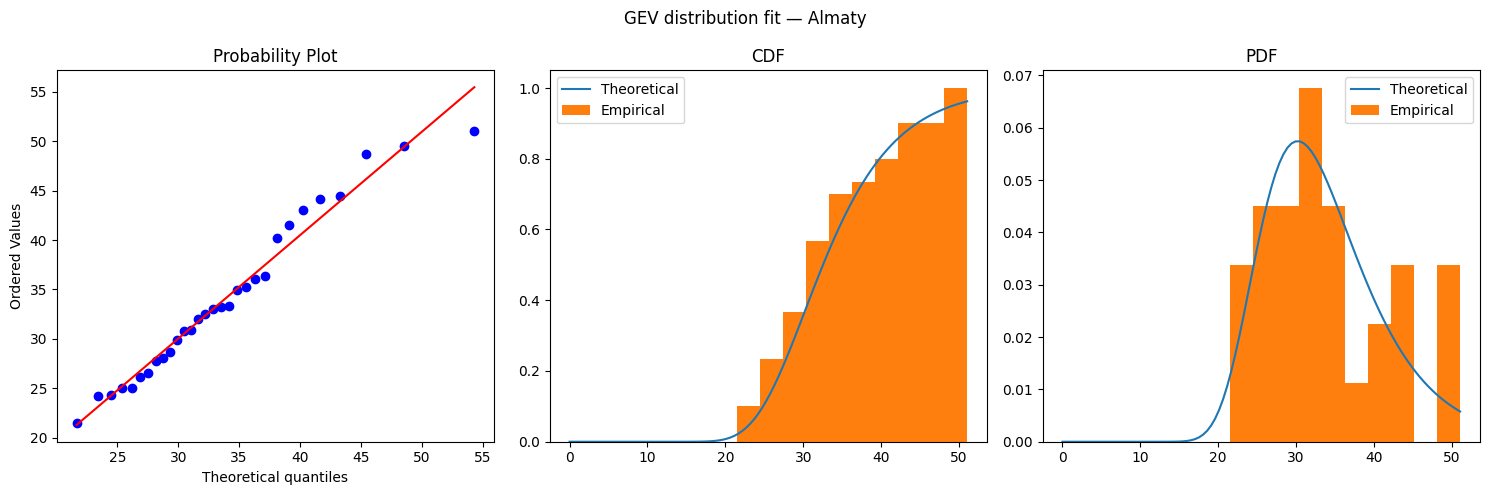

Distribution : genextreme
Parameters   : shape=0.0006, loc=30.1881, scale=6.4053


In [8]:
def do_fitting(ts_max, distributions=None, do_plots=False):
    """
    Fit a probability distribution to a 1-D annual maximum series.
    Returns (best_distribution, parameters).

    Unchanged from the original CLIMAAX workflow.

    Parameters
    ----------
    ts_max        : 1-D array of annual maximum precipitation values [mm/day]
    distributions : list of scipy.stats distributions to test (default: [genextreme])
    do_plots      : if True, plot theoretical vs empirical CDF and PDF
    """
    if distributions is None:
        distributions = [genextreme]

    param   = {}
    ks_test = {}

    for dist in distributions:
        param[dist]   = dist.fit(ts_max)
        ks_test[dist] = ks_1samp(ts_max, dist.cdf, param[dist])

        if do_plots:
            x = np.linspace(0, np.max(ts_max), 100)
            fig, ax = plt.subplots(1, 3, figsize=(15, 5))
            sst.probplot(ts_max, dist=dist, sparams=param[dist], plot=ax[0])
            ax[1].plot(x, dist.cdf(x, *param[dist]))
            ax[1].hist(ts_max, density=True, cumulative=True)
            ax[1].set_title('CDF')
            ax[1].legend(['Theoretical', 'Empirical'])
            ax[2].plot(x, dist.pdf(x, *param[dist]))
            ax[2].hist(ts_max, density=True)
            ax[2].set_title('PDF')
            ax[2].legend(['Theoretical', 'Empirical'])
            plt.suptitle(f'GEV distribution fit — {POINT_LABEL}')
            plt.tight_layout()
            plt.show()

    best_fit = min(ks_test, key=ks_test.get)
    return best_fit, param[best_fit]


# Example: fit at the example pixel
ds_fit = xr.open_dataset(
    data_dir / f'pr_annualMax_24h_GFDL-ESM4_ssp370_{TIME_FRAMES["ssp370"][0]}-{TIME_FRAMES["ssp370"][1]}.nc'
)
ts_fit = ds_fit.pr_max.sel(lat=POINT_LAT, lon=POINT_LON, method='nearest').values
ds_fit.close()

dist_sel, param_sel = do_fitting(ts_fit, [genextreme], do_plots=True)
print(f'Distribution : {dist_sel.name}')
print(f'Parameters   : shape={param_sel[0]:.4f}, loc={param_sel[1]:.4f}, scale={param_sel[2]:.4f}')

## Step 5: Expected precipitation for different return periods

Unchanged from the original CLIMAAX workflow.
Computes return values and 95% confidence intervals using the
frequency factor method (Chow et al. 1988).

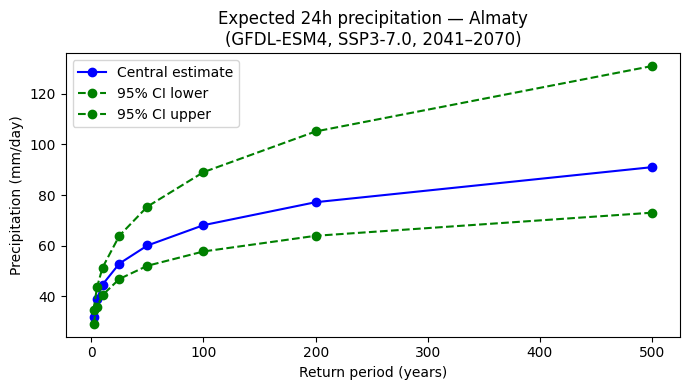

In [9]:
def adjust_extreme_prec(ts_max, dist_fit=None, param_fit=None, ret_per=None):
    """
    Compute expected precipitation for given return periods with 95% CI.
    Returns array of shape (3, n_return_periods): [central, lower_CI, upper_CI].

    Unchanged from the original CLIMAAX workflow.
    """
    if param_fit is None and dist_fit is None:
        dist_fit, param_fit = do_fitting(ts_max)
    elif not param_fit:
        dist_fit, param_fit = do_fitting(ts_max, dist_fit)

    if ret_per is None:
        ret_per = RETURN_PERIODS

    n        = ts_max.size
    data_log = np.log(ts_max)

    # GEV special cases: shape=0 → Gumbel (Type I), shape≠0 → GEV II/III
    if param_fit[0] == 0:
        data = ts_max
    else:
        data = data_log

    normal_level      = np.power(1.96, 2)
    a                 = 1 - normal_level / 2 / (n - 1)
    freq_factor       = (
        -np.sqrt(6) / np.pi
        * (0.5772 + np.log(np.log(ret_per / (ret_per - 1))))
    )
    b                 = np.power(freq_factor, 2) - normal_level / n
    data_mean         = data.mean()
    data_std          = data.std()
    ff_upper          = freq_factor + np.sqrt(np.power(freq_factor, 2) - a * b)
    ff_lower          = freq_factor - np.sqrt(np.power(freq_factor, 2) - a * b)
    return_value      = data_mean + freq_factor * data_std
    ci = [
        return_value,
        data_mean + data_std * ff_lower / a,
        data_mean + data_std * ff_upper / a,
    ]
    if param_fit[0] != 0:
        ci = np.exp(ci)

    return np.asarray(ci)


# Example frequency curve at the example pixel
ds_rp = xr.open_dataset(
    data_dir / (
        f'pr_annualMax_24h_GFDL-ESM4_ssp370'
        f'_{TIME_FRAMES["ssp370"][0]}-{TIME_FRAMES["ssp370"][1]}.nc'
    )
)
ts_rp = ds_rp.pr_max.sel(lat=POINT_LAT, lon=POINT_LON, method='nearest').values
ds_rp.close()

exp_prec = adjust_extreme_prec(ts_rp, ret_per=RETURN_PERIODS)

fig_rp, ax_rp = plt.subplots(figsize=(7, 4))
ax_rp.plot(RETURN_PERIODS, exp_prec[0], '-bo',
           RETURN_PERIODS, exp_prec[1], '--go',
           RETURN_PERIODS, exp_prec[2], '--go')
ax_rp.set_xlabel('Return period (years)')
ax_rp.set_ylabel('Precipitation (mm/day)')
ax_rp.set_title(
    f'Expected 24h precipitation — {POINT_LABEL}\n'
    f'(GFDL-ESM4, SSP3-7.0, 2041–2070)'
)
ax_rp.legend(['Central estimate', '95% CI lower', '95% CI upper'])
plt.tight_layout()
fig_rp.savefig(plots_dir / f'expected_prec_24h_2041-2070_{POINT_LABEL}.png')
plt.show()

## Step 6: Apply to the entire region — all models, multi-model mean

For each model and scenario, `adjust_extreme_prec` is applied to every pixel
using `numpy.apply_along_axis` (same approach as the original CLIMAAX workflow).
Per-model IDF NetCDFs are saved, then averaged to produce a 5-model mean.

**NaN protection:** pixels with fewer than 5 valid years or any NaN are skipped
(set to NaN in output). This handles water bodies (Aral Sea, Caspian) within
the bounding box.

In [10]:
def _safe_idf_pixel(ts_max, dist_fit, ret_per):
    """
    Wrapper around adjust_extreme_prec with NaN protection.
    Returns flattened (3 × n_rp,) array; fills NaN on failure.
    Called by np.apply_along_axis — must return 1-D array.
    """
    n_rp   = len(ret_per)
    nan_out = np.full(3 * n_rp, np.nan)

    if np.any(np.isnan(ts_max)) or np.sum(ts_max > 0) < 5:
        return nan_out
    try:
        result = adjust_extreme_prec(
            ts_max, dist_fit=dist_fit, ret_per=ret_per
        )
        return result.flatten()   # (3, n_rp) → (3*n_rp,)
    except Exception:
        return nan_out


def compute_idf_region(model, scenario, year_start, year_end):
    """
    Compute IDF values for every pixel over Kazakhstan.
    Saves result as NetCDF in results_dir. Returns output Path.

    Output variables: idf, lower_ci, upper_ci
    Dimensions: (return_period, lat, lon)

    Substitution note:
      - Original uses rotated-pole (rlat, rlon) coordinates with a duration dim
      - Here: standard lat/lon, no duration dimension (24h only)
      - apply_along_axis axis=0 iterates along the time axis of (n_years, n_lat, n_lon)
    """
    out_fname = f'idf_24h_{model}_{scenario}_{year_start}-{year_end}.nc'
    out_path  = results_dir / out_fname

    if out_path.exists():
        print(f'  Cached: {out_fname}')
        return out_path

    in_path = data_dir / f'pr_annualMax_24h_{model}_{scenario}_{year_start}-{year_end}.nc'
    print(f'  Loading {in_path.name}...')

    ds_in         = xr.open_dataset(in_path)
    data          = ds_in.pr_max.values    # shape: (n_years, n_lat, n_lon)
    lat_vals      = ds_in.lat.values
    lon_vals      = ds_in.lon.values
    n_years, n_lat, n_lon = data.shape
    n_rp          = len(RETURN_PERIODS)

    print(f'  Fitting GEV to {n_lat * n_lon} pixels...')

    # apply_along_axis: func receives 1-D array of shape (n_years,) per pixel
    # returns (3*n_rp,); assembled result shape: (3*n_rp, n_lat, n_lon)
    idf_flat = np.apply_along_axis(
        _safe_idf_pixel, 0, data,
        dist_fit=[DISTRIBUTION],
        ret_per=RETURN_PERIODS,
    )
    # Reshape to (3, n_rp, n_lat, n_lon)
    idf_raw = idf_flat.reshape(3, n_rp, n_lat, n_lon)

    ds_out = xr.Dataset(
        {
            'idf': (
                ['return_period', 'lat', 'lon'],
                idf_raw[0],
                {'units': 'mm/day', 'long_name': 'Expected 24h precipitation'},
            ),
            'lower_ci': (
                ['return_period', 'lat', 'lon'],
                idf_raw[1],
                {'units': 'mm/day', 'long_name': '95% CI lower bound'},
            ),
            'upper_ci': (
                ['return_period', 'lat', 'lon'],
                idf_raw[2],
                {'units': 'mm/day', 'long_name': '95% CI upper bound'},
            ),
            'prob_dist': ([], DISTRIBUTION.name),
        },
        coords={
            'return_period': RETURN_PERIODS,
            'lat':           lat_vals,
            'lon':           lon_vals,
        },
    )
    ds_out.attrs['model']    = model
    ds_out.attrs['scenario'] = scenario
    ds_out.attrs['period']   = f'{year_start}-{year_end}'

    ds_out.to_netcdf(out_path)
    ds_in.close()
    print(f'  Saved: {out_fname}')
    return out_path


# ---------------------------------------------------------------------------
# Execute for all models and scenarios
# ---------------------------------------------------------------------------
print('Computing per-pixel IDF for all models...\n')
for scenario, (ystart, yend) in TIME_FRAMES.items():
    print(f'Scenario: {scenario} ({ystart}–{yend})')
    for model in tqdm(MODELS, desc='  Models'):
        compute_idf_region(model, scenario, ystart, yend)
    print()

Computing per-pixel IDF for all models...

Scenario: historical (1976–2005)


  Models:   0%|          | 0/5 [00:00<?, ?it/s]

  Loading pr_annualMax_24h_GFDL-ESM4_historical_1976-2005.nc...
  Fitting GEV to 2490 pixels...


  Models:  20%|██        | 1/5 [01:15<05:03, 75.87s/it]

  Saved: idf_24h_GFDL-ESM4_historical_1976-2005.nc
  Loading pr_annualMax_24h_IPSL-CM6A-LR_historical_1976-2005.nc...
  Fitting GEV to 2490 pixels...


...

  Saved: idf_24h_MPI-ESM1-2-HR_ssp370_2041-2070.nc
  Loading pr_annualMax_24h_MRI-ESM2-0_ssp370_2041-2070.nc...
  Fitting GEV to 2490 pixels...


  Models:  80%|████████  | 4/5 [05:10<01:15, 75.69s/it]

  Saved: idf_24h_MRI-ESM2-0_ssp370_2041-2070.nc
  Loading pr_annualMax_24h_UKESM1-0-LL_ssp370_2041-2070.nc...
  Fitting GEV to 2490 pixels...


  Models: 100%|██████████| 5/5 [06:28<00:00, 77.62s/it]

  Saved: idf_24h_UKESM1-0-LL_ssp370_2041-2070.nc



In [11]:
# ---------------------------------------------------------------------------
# Multi-model mean IDF
# ---------------------------------------------------------------------------
print('Computing 5-model mean IDF...\n')

for scenario, (ystart, yend) in TIME_FRAMES.items():
    out_fname = f'idf_24h_multimodel_{scenario}_{ystart}-{yend}.nc'
    out_path  = results_dir / out_fname

    if out_path.exists():
        print(f'Cached: {out_fname}')
        continue

    open_ds    = []
    idf_arrays = []
    for model in MODELS:
        p    = results_dir / f'idf_24h_{model}_{scenario}_{ystart}-{yend}.nc'
        ds_m = xr.open_dataset(p)
        open_ds.append(ds_m)
        idf_arrays.append(ds_m['idf'])

    idf_stack = xr.concat(idf_arrays, dim='model').assign_coords(model=MODELS)
    idf_mean  = idf_stack.mean(dim='model', skipna=True).rename('idf')

    ds_mean = idf_mean.to_dataset()
    ds_mean.attrs['models']   = ', '.join(MODELS)
    ds_mean.attrs['scenario'] = scenario
    ds_mean.attrs['period']   = f'{ystart}-{yend}'
    ds_mean.to_netcdf(out_path)
    for ds_m in open_ds:
        ds_m.close()
    print(f'Saved: {out_fname}')

Computing 5-model mean IDF...

Saved: idf_24h_multimodel_historical_1976-2005.nc
Saved: idf_24h_multimodel_ssp126_2041-2070.nc
Saved: idf_24h_multimodel_ssp370_2041-2070.nc


## Step 7: Precipitation changes relative to historical baseline

Compute the change (%) in expected 24h precipitation for each SSP scenario
(2041–2070) relative to the historical baseline (1976–2005), using multi-model
mean IDF values. This is the direct equivalent of Step 7 in the original workflow.

In [12]:
hist_ystart, hist_yend = TIME_FRAMES['historical']
ds_hist = xr.open_dataset(
    results_dir / f'idf_24h_multimodel_historical_{hist_ystart}-{hist_yend}.nc'
)
data_hist = ds_hist['idf'].values

for scenario in ['ssp126', 'ssp370']:
    ystart, yend = TIME_FRAMES[scenario]
    out_fname    = f'idf_24h_multimodel_{scenario}_{ystart}-{yend}_change.nc'
    out_path     = results_dir / out_fname

    if out_path.exists():
        print(f'Cached: {out_fname}')
        continue

    ds_fut   = xr.open_dataset(
        results_dir / f'idf_24h_multimodel_{scenario}_{ystart}-{yend}.nc'
    )
    data_fut = ds_fut['idf'].values
    change   = (data_fut - data_hist) / np.where(data_hist > 0, data_hist, np.nan) * 100

    ds_change = xr.Dataset(
        {
            'idf_change': (
                ['return_period', 'lat', 'lon'],
                change,
                {
                    'units':     '%',
                    'long_name': (
                        f'Change in 24h IDF relative to historical '
                        f'{hist_ystart}-{hist_yend}'
                    ),
                },
            )
        },
        coords={
            'return_period': ds_fut.return_period.values,
            'lat':           ds_fut.lat.values,
            'lon':           ds_fut.lon.values,
        },
    )
    ds_change.attrs['scenario'] = scenario
    ds_change.attrs['baseline'] = f'historical {hist_ystart}-{hist_yend}'
    ds_change.attrs['future']   = f'{ystart}-{yend}'
    ds_change.to_netcdf(out_path)
    print(f'Saved: {out_fname}')
    ds_fut.close()

ds_hist.close()

Saved: idf_24h_multimodel_ssp126_2041-2070_change.nc
Saved: idf_24h_multimodel_ssp370_2041-2070_change.nc


## Step 8: Plot results

### Extreme precipitation maps

For each SSP scenario: absolute IDF (mm/day) and relative change (%) vs
historical baseline, for the selected return period.
Kazakhstan boundary overlay from the project shapefile.

In [13]:
# Load Kazakhstan boundary for overlay
kaz_gdf      = gpd.read_file(SHAPEFILE_PATH)
kaz_boundary = kaz_gdf.dissolve()

# Colormap for absolute precipitation (same palette as original CLIMAAX workflow)
z_pal   = [0., 10., 20, 25, 30, 35, 40, 45, 50, 60., 70., 80, 90., 100., 110, 120., 130, 140]
pal_rgb = [
    '#ffffff00', '#d6e2ffff', '#8db2ffff', '#626ff7ff', '#0062ffff',
    '#019696ff', '#01c634ff', '#63ff01ff', '#c6ff34ff', '#ffff02ff',
    '#ffc601ff', '#ffa001ff', '#ff7c00ff', '#ff1901ff', '#a20a28ff',
    '#9b159dff', '#d294d3ff', '#f6e9f6ff',
]
cmap_prec, norm_prec = from_levels_and_colors(z_pal, pal_rgb, extend='max')

Saved: prec_map_24h_ssp126_2041-2070_RP100.png


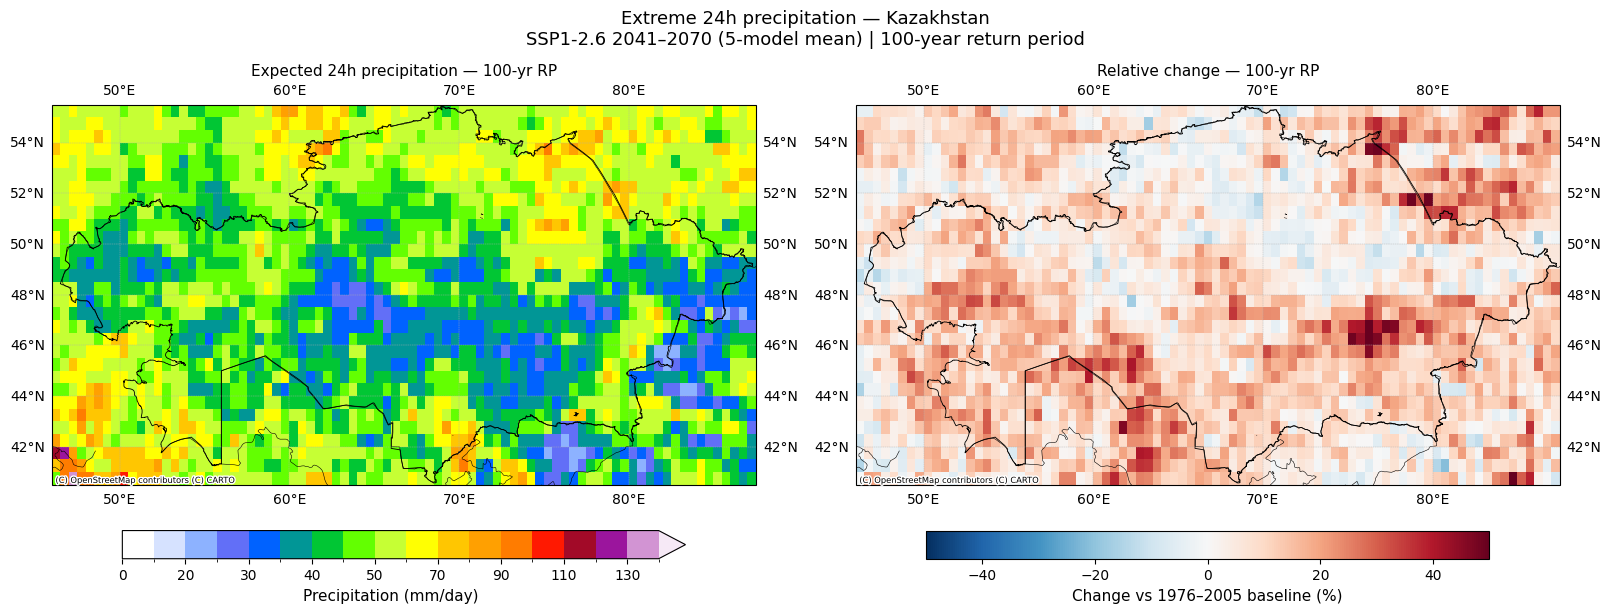

Saved: prec_map_24h_ssp370_2041-2070_RP100.png


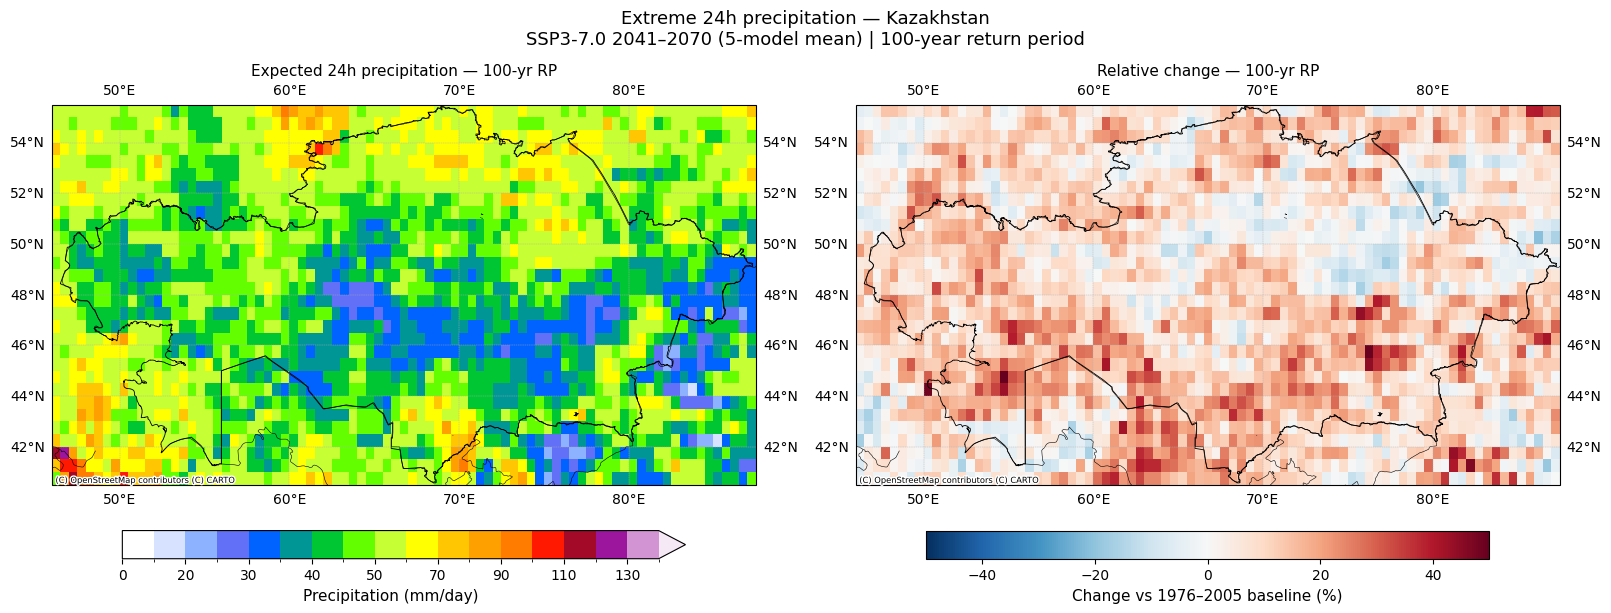

In [14]:
for scenario in ['ssp126', 'ssp370']:
    ystart, yend = TIME_FRAMES[scenario]
    scen_label   = 'SSP1-2.6' if scenario == 'ssp126' else 'SSP3-7.0'

    ds_fut    = xr.open_dataset(
        results_dir / f'idf_24h_multimodel_{scenario}_{ystart}-{yend}.nc'
    )
    ds_change = xr.open_dataset(
        results_dir / f'idf_24h_multimodel_{scenario}_{ystart}-{yend}_change.nc'
    )

    da_idf    = ds_fut['idf'].sel(return_period=RETURN_PERIOD_MAP)
    da_change = ds_change['idf_change'].sel(return_period=RETURN_PERIOD_MAP)

    fig, axs = plt.subplots(
        1, 2,
        figsize=(16, 6),
        subplot_kw={'projection': ccrs.PlateCarree()},
        constrained_layout=True,
    )
    fig.suptitle(
        f'Extreme 24h precipitation — {areaname}\n'
        f'{scen_label} 2041–2070 (5-model mean)'
        f' | {RETURN_PERIOD_MAP}-year return period',
        fontsize=13,
    )

    # Left: absolute IDF
    im0 = da_idf.plot(
        ax=axs[0], norm=norm_prec, cmap=cmap_prec,
        add_colorbar=False, transform=ccrs.PlateCarree(),
    )
    kaz_boundary.boundary.plot(
        ax=axs[0], color='black', linewidth=0.6,
        transform=ccrs.PlateCarree(),
    )
    cbar0 = fig.colorbar(im0, ax=axs[0], orientation='horizontal', shrink=0.8)
    cbar0.set_label('Precipitation (mm/day)', fontsize=11)
    axs[0].set_title(f'Expected 24h precipitation — {RETURN_PERIOD_MAP}-yr RP', fontsize=11)
    axs[0].add_feature(cfeature.BORDERS, linewidth=0.4)
    axs[0].gridlines(draw_labels=True, linewidth=0.3, linestyle='--')
    ctx.add_basemap(
        ax=axs[0], crs='EPSG:4326',
        source=ctx.providers.CartoDB.Positron,
        attribution_size=6,
    )

    # Right: relative change
    im1 = da_change.plot(
        ax=axs[1], cmap='RdBu_r', vmin=-50, vmax=50,
        add_colorbar=False, transform=ccrs.PlateCarree(),
    )
    kaz_boundary.boundary.plot(
        ax=axs[1], color='black', linewidth=0.6,
        transform=ccrs.PlateCarree(),
    )
    cbar1 = fig.colorbar(im1, ax=axs[1], orientation='horizontal', shrink=0.8)
    cbar1.set_label(
        f'Change vs {hist_ystart}–{hist_yend} baseline (%)', fontsize=11
    )
    axs[1].set_title(
        f'Relative change — {RETURN_PERIOD_MAP}-yr RP', fontsize=11
    )
    axs[1].add_feature(cfeature.BORDERS, linewidth=0.4)
    axs[1].gridlines(draw_labels=True, linewidth=0.3, linestyle='--')
    ctx.add_basemap(
        ax=axs[1], crs='EPSG:4326',
        source=ctx.providers.CartoDB.Positron,
        attribution_size=6,
    )

    out_fig = plots_dir / f'prec_map_24h_{scenario}_2041-2070_RP{RETURN_PERIOD_MAP}.png'
    fig.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_fig.name}')
    plt.show()

    ds_fut.close()
    ds_change.close()

### Precipitation vs. frequency curves (Kazakhstan spatial mean)

Multi-model mean IDF spatially averaged over Kazakhstan, for the historical
baseline and both SSP scenarios — direct equivalent of Step 8 in original.

In [15]:
fig_freq = go.Figure(layout={'width': 1000, 'height': 500})

# Historical
_h_ys, _h_ye = TIME_FRAMES['historical']
ds_h  = xr.open_dataset(
    results_dir / f'idf_24h_multimodel_historical_{_h_ys}-{_h_ye}.nc'
)
mean_h = ds_h['idf'].mean(dim=['lat', 'lon'], skipna=True)
df_h   = mean_h.to_dataframe().reset_index()
fig_freq.add_trace(go.Scatter(
    x=df_h['return_period'], y=df_h['idf'],
    name=f'Historical {_h_ys}–{_h_ye}',
    line=dict(color='black', width=2),
))
ds_h.close()

# SSP scenarios
_colors = {'ssp126': 'steelblue', 'ssp370': 'tomato'}
_labels = {'ssp126': 'SSP1-2.6 2041–2070', 'ssp370': 'SSP3-7.0 2041–2070'}

for scenario in ['ssp126', 'ssp370']:
    ystart, yend = TIME_FRAMES[scenario]
    ds_s   = xr.open_dataset(
        results_dir / f'idf_24h_multimodel_{scenario}_{ystart}-{yend}.nc'
    )
    mean_s = ds_s['idf'].mean(dim=['lat', 'lon'], skipna=True)
    df_s   = mean_s.to_dataframe().reset_index()
    fig_freq.add_trace(go.Scatter(
        x=df_s['return_period'], y=df_s['idf'],
        name=_labels[scenario],
        line=dict(color=_colors[scenario], width=2),
    ))
    ds_s.close()

fig_freq.update_layout(
    yaxis=dict(title='Precipitation (mm/day)'),
    xaxis=dict(title='Return period (years)'),
    title=(
        f'Mean 24h precipitation over {areaname} — 5-model mean<br>'
        f'Historical vs SSP1-2.6 vs SSP3-7.0 (2041–2070)'
    ),
)
fig_freq.show()
fig_freq.write_image(
    str(plots_dir / 'mean_prec_24h_historical_ssp126_ssp370.png')
)
print('Saved: mean_prec_24h_historical_ssp126_ssp370.png')

Saved: mean_prec_24h_historical_ssp126_ssp370.png


## Kazakhstan-specific interpretation notes

- **Resolution:** ISIMIP3b at 0.5° (~55 km at Kazakhstan's latitudes) is coarser
  than EURO-CORDEX's 12 km. Results represent oblast-scale climate signals, not
  local convective events. Point-scale extremes will be underestimated.
- **Orographic effects:** The Tian Shan and Altai ranges generate strong
  precipitation gradients that 0.5° resolution smooths considerably. Interpret
  mountain-adjacent pixels with caution.
- **Arid regions:** Much of southern and western Kazakhstan receives <200 mm/year.
  GEV fitting with 30 data points is sensitive in very dry pixels — inspect the
  per-pixel CI width (`upper_ci - lower_ci`) to flag uncertain estimates.
- **Multi-model spread:** The 5-model mean reduces single-model uncertainty.
  Load per-model IDF files from `results_Kazakhstan/idf_24h_{model}_...nc`
  to examine model spread.
- **Sub-daily limitation:** Flash floods and convective storm extremes cannot
  be assessed from daily data. ERA5 hourly reanalysis (Copernicus CDS) can
  supplement this analysis for the historical period if sub-daily resolution
  is needed, though it requires a separate CDS API registration and introduces
  a methodological inconsistency with the ISIMIP3b future projections.

---
## Authors
Adapted for Kazakhstan by Ramazan Dauletov.
Original workflow by CRAHI-UPC (Meléndez-Landaverde et al.) for CLIMAAX.

## References
- Chow, V.T., Maidment, D.R., Mays, L.W. (1988). *Applied Hydrology*. McGraw-Hill.
- Fisher, R.A., Tippett, L.H.C. (1928). Limiting forms of the frequency distribution.
  *Math. Proc. Cambridge Phil. Soc.* 24(2), 180–190.
- Jenkinson, A.F. (1955). The frequency distribution of annual maximum values.
  *QJRMS* 81(348), 158–171.
- Lange, S. (2019). Trend-preserving bias adjustment and statistical downscaling
  with ISIMIP3BASD. *Geosci. Model Dev.* 12, 3055–3070.